In [22]:
import importlib
import sys

# Hapus cache module yang salah
if 'serial' in sys.modules:
    del sys.modules['serial']

import serial
print(serial.Serial)  # Harus muncul <class 'serial.serialutil.Serial'>

<class 'serial.serialwin32.Serial'>


C:\Users\rizki\AppData\Local\Temp\ipykernel_568\13614962.py:34: UserWarning: frames=None which we can infer the length of, did not pass an explicit *save_count* and passed cache_frame_data=True.  To avoid a possibly unbounded cache, frame data caching has been disabled. To suppress this warning either pass `cache_frame_data=False` or `save_count=MAX_FRAMES`.
  ani = animation.FuncAnimation(fig, update, interval=10)
c:\Users\rizki\anaconda3\Lib\site-packages\matplotlib\animation.py:908: UserWarning: Animation was deleted without rendering anything. This is most likely not intended. To prevent deletion, assign the Animation to a variable, e.g. `anim`, that exists until you output the Animation using `plt.show()` or `anim.save()`.
  warnings.warn(


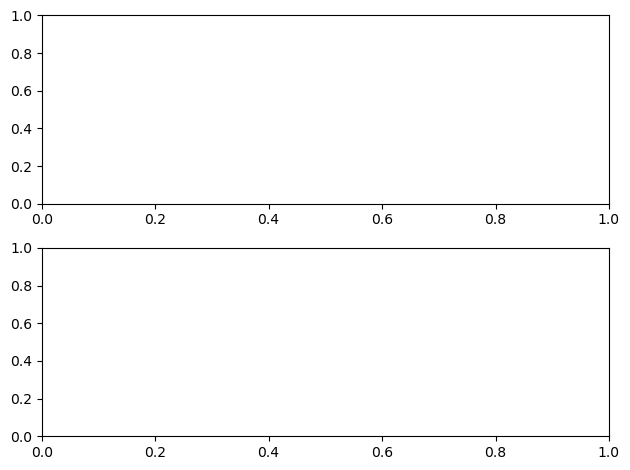

In [23]:
import serial
import matplotlib.pyplot as plt
import matplotlib.animation as animation

ser = serial.Serial('COM20', 115200)  # ganti COM port

ecg_data = []
pcg_data = []

fig, (ax1, ax2) = plt.subplots(2, 1)

def update(frame):
    line = ser.readline().decode().strip()
    try:
        ecg, pcg = map(int, line.split(','))
        ecg_data.append(ecg)
        pcg_data.append(pcg)

        if len(ecg_data) > 200:
            ecg_data.pop(0)
            pcg_data.pop(0)

        ax1.cla()
        ax2.cla()
        ax1.set_title('ECG')
        ax2.set_title('PCG')
        ax1.plot(ecg_data, color='red')
        ax2.plot(pcg_data, color='blue')
        ax1.set_ylim(0, 4095)
        ax2.set_ylim(0, 4095)
    except:
        pass

ani = animation.FuncAnimation(fig, update, interval=10)
plt.tight_layout()
plt.show()